# Packages

In [2]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

import plotly.graph_objects as go


****
# Observing and controlling

## While sim is running

In [2]:
log_dir = "/home/b/bkoberg/logs"
err_files = glob.glob(os.path.join(log_dir, "*.err"))
non_empty_err_files = [f for f in err_files if os.path.getsize(f) > 0]

print("Nicht-leere .err Dateien:")
for f in non_empty_err_files:
    print(f)

Nicht-leere .err Dateien:


In [6]:
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        perc = re.search(r"(\d+)%", lines[-1].strip())
        begin = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[458].strip())
        now = re.search(r"(\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())
        end = re.search(r"ETA: (\d{4}-\d{1,2}-\d{1,2} \d{1,2}-\d{1,2}-\d{1,2})", lines[-1].strip())

        fmt = "%Y-%m-%d %H-%M-%S"
        dt_start = datetime.strptime(begin.group(1), fmt) if begin else None
        dt_now = datetime.strptime(now.group(1), fmt) if now else None
        dt_ende = datetime.strptime(end.group(1), fmt) if end else None

        rows.append({
            "File": os.path.basename(file),
            "Progress": perc.group(1) if perc else None,
            "begin": dt_start,
            "end": dt_ende,
            "now": dt_now,
            "Time to go": (dt_ende - dt_now) if (dt_ende and dt_now) else None,
            "Total Time": (dt_ende - dt_start) if (dt_ende and dt_start) else None
        })

df = pd.DataFrame(rows)


max_time = df.loc[df["Time to go"].idxmax()]
max_total_time = df.loc[df["Total Time"].idxmax()]
print("=== MAX TIME TO GO ===")
print(max_time)
print("\n=== MAX TOTAL TIME ===")
print(max_total_time)

df_wak = df.sort_values(by="Time to go", ascending=False)
df_wak = df_wak[df_wak['Time to go'].notna()]
print("\n=== SORTED BY TIME TO GO ===")
df_wak

=== MAX TIME TO GO ===
File          simulation-33337003.out
Progress                            0
begin             2025-07-24 18:09:17
end               2025-07-25 15:28:10
now               2025-07-24 18:09:17
Time to go            0 days 21:18:53
Total Time            0 days 21:18:53
Name: 586, dtype: object

=== MAX TOTAL TIME ===
File          simulation-33337003.out
Progress                            0
begin             2025-07-24 18:09:17
end               2025-07-25 15:28:10
now               2025-07-24 18:09:17
Time to go            0 days 21:18:53
Total Time            0 days 21:18:53
Name: 586, dtype: object

=== SORTED BY TIME TO GO ===


,File,Progress,begin,end,now,Time to go,Total Time
586,simulation-33337003.out,0,2025-07-24 18:09:17,2025-07-25 15:28:10,2025-07-24 18:09:17,0 days 21:18:53,0 days 21:18:53
853,simulation-33337002.out,0,2025-07-24 18:09:08,2025-07-25 12:56:03,2025-07-24 18:11:42,0 days 18:44:21,0 days 18:46:55
470,simulation-33337005.out,0,2025-07-24 18:08:55,2025-07-25 11:27:47,2025-07-24 18:11:17,0 days 17:16:30,0 days 17:18:52
80,simulation-33337006.out,0,2025-07-24 18:08:52,2025-07-25 11:11:45,2025-07-24 18:11:11,0 days 17:00:34,0 days 17:02:53
920,simulation-33337004.out,0,2025-07-24 18:08:51,2025-07-25 10:56:13,2025-07-24 18:11:09,0 days 16:45:04,0 days 16:47:22
...,...,...,...,...,...,...,...
524,simulation-33332914.out,31,2025-07-24 13:30:09,2025-07-25 04:28:20,2025-07-24 18:10:26,0 days 10:17:54,0 days 14:58:11
265,simulation-33333104.out,31,2025-07-24 13:30:12,2025-07-25 04:28:20,2025-07-24 18:10:57,0 days 10:17:23,0 days 14:58:08
834,simulation-33333106.out,31,2025-07-24 13:30:11,2025-07-25 04:28:20,2025-07-24 18:11:37,0 days 10:16:43,0 days 14:58:09
340,simulation-33332915.out,31,2025-07-24 13:30:08,2025-07-25 04:28:20,2025-07-24 18:11:38,0 days 10:16:42,0 days 14:58:12


## After controle

In [6]:
log_dir = "/home/b/bkoberg/logs"
out_files = glob.glob(os.path.join(log_dir, "*.out"))

rows = []

for i, file in enumerate(out_files):
    with open(file, "r") as f:
        lines = f.readlines()

        

        exit_code_match = re.search(r"State:\s*(.*)", lines[-8].strip())
        if not exit_code_match:
            exit_code_match = re.search(r"State:\s*(.*)", lines[-9].strip())

        time_match = re.search(r"(\d{1,2}:\d{1,2}:\d{1,2})", lines[-4].strip())
        time = datetime.strptime(time_match.group(1), "%H:%M:%S") if time_match else None

        rows.append({
            "File": os.path.basename(file),
            "Exit Code": exit_code_match.group(1) if exit_code_match else None,
            "Lines": len(lines),
            "Time": time,
        })

df = pd.DataFrame(rows)

df_wak = df[df['Exit Code'] != 'COMPLETED (exit code 0)'] # either new datei or RUNNING

row_min = df.loc[df["Time"].idxmax()]
df_wak

,File,Exit Code,Lines,Time
2,simulation-33208706.out,None,845,NaT
3,simulation-33208897.out,None,833,NaT
4,simulation-33208750.out,None,843,NaT
6,simulation-33208844.out,None,832,NaT
7,simulation-33208598.out,None,836,NaT
...,...,...,...,...
241,simulation-33208710.out,None,830,NaT
242,simulation-33208658.out,None,829,NaT
244,simulation-33208760.out,None,829,NaT
245,simulation-33208815.out,None,848,NaT


# Sachen die ich actually brauche


## Einzeln

In [6]:
grouped_index

array(['Xe132', 'Xe130', 'Xe133(1)', 'Xe135(1)', 'Xe137', 'Xe131(1)',
       'Xe129', 'Xe133', 'Xe125', 'Xe127', 'Xe127(1)', 'Xe131', 'Xe135',
       'Xe132(2)', 'Xe129(1)', 'Xe125(1)'], dtype='<U8')

In [8]:
path_Version = "4_7e82d44"
path_Material = "NoAbsorber"  # NoAbsorber
path_length = "10cm"

print(f"Konfiguration: {path_Version}, {path_Material}, {path_length}")

path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/NC_in_LXe_2.npz"
grouped_index = np.load(path, allow_pickle=True)['grouped_index']
grouped_data_values = np.load(path, allow_pickle=True)['grouped_data']
laenge = np.load(path, allow_pickle=True)['laenge']
bins = np.load(path, allow_pickle=True)['bins']


histograms = {name: data for name, data in zip(grouped_index, grouped_data_values)}

Konfiguration: 4_7e82d44, NoAbsorber, 10cm


In [9]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [10]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic', 'CoulombScat']
volumes = ['e_pri', 'Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

In [11]:
histograms_normalized = {key: histograms[key] / laenge * 100 for key in histograms}

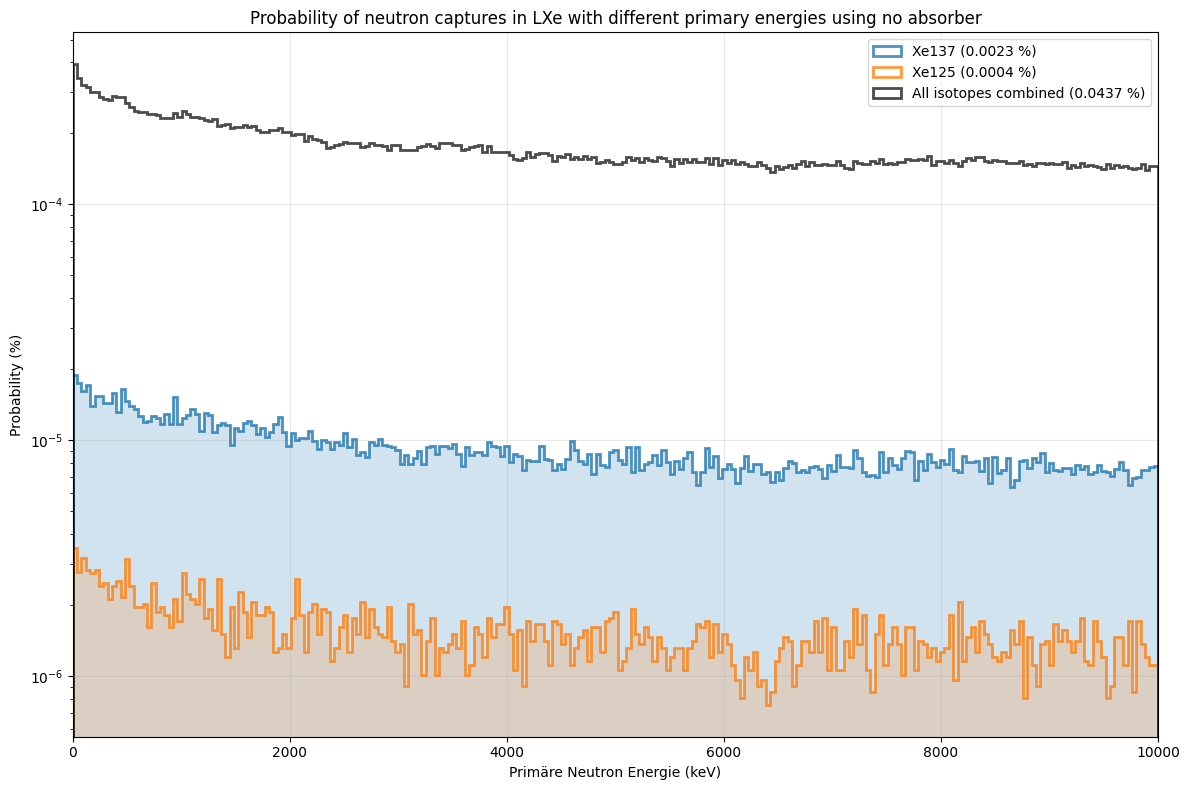


=== TOP 5 PARTIKEL ENERGIE-SPEKTREN (normiert) ===
1. Xe137          : 2.28e-03 norm. (  5.2%) - Peak bei 20 keV
2. Xe125          : 3.83e-04 norm. (  0.9%) - Peak bei 20 keV


In [12]:
# Sortiere Partikel nach Gesamtzahl der Counts (Top 5)
sorted_particles = sorted(histograms_normalized.items(), key=lambda x: x[1].sum(), reverse=True)
chosen_particles = [part for part in sorted_particles if part[0] in ['Xe137', 'Xe125']][:5]
#chosen_particles = [part for part in sorted_particles][:5]

# Erstelle Energie-Spektren Plot
plt.figure(figsize=(12, 8))

bin_centers = (bins[:-1] + bins[1:]) / 2
total_histogram = np.zeros_like(list(histograms_normalized.values())[0])

# Plot der Top 5 Partikel als einzelne Spektren
for i, (particle_name, hist_vals) in enumerate(chosen_particles):
        total_histogram += hist_vals
        
        plt.hist(bin_centers, bins=bins, weights=hist_vals,
                        histtype='step', linewidth=2, color=colors[i],
                        label=f'{particle_name} ({hist_vals.sum():.4f} %)', alpha=0.8)
        
        plt.hist(bin_centers, bins=bins, weights=hist_vals,
                        histtype='stepfilled', color=colors[i], alpha=0.2)

# Optional: Zeige auch die Gesamtsumme aller Partikel
total_all = sum([data.sum() for _, data in histograms_normalized.items()])
all_combined = np.zeros_like(list(histograms_normalized.values())[0])
for _, data in histograms_normalized.items():
        all_combined += data

plt.hist(bin_centers, bins=bins, weights=all_combined,
                histtype='step', linewidth=2, color='black',
                label=f'All isotopes combined ({total_all:.4f} %)', alpha=0.7)

plt.xlabel('Primäre Neutron Energie (keV)')
plt.ylabel('Probability (%)')
plt.title(f'Probability of neutron captures in LXe with different primary energies using no absorber')
plt.yscale('log')
plt.xlim(0, 10000)
#plt.ylim(0.5 * all_combined[all_combined > 0].min(), all_combined.max() * 2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/NC_EnergySpectra_chosen.pdf", 
                        bbox_inches='tight', dpi=300)
plt.show()

# Zusätzlich: Prozentuale Anteile der Top 5
print(f"\n=== TOP 5 PARTIKEL ENERGIE-SPEKTREN (normiert) ===")
for i, (name, data) in enumerate(chosen_particles):
        percentage = (data.sum() / total_all) * 100
        peak_energy = bin_centers[np.argmax(data)]
        print(f"{i+1}. {name:15s}: {data.sum():.2e} norm. ({percentage:5.1f}%) - Peak bei {peak_energy:.0f} keV")

### Schöne Abbildung


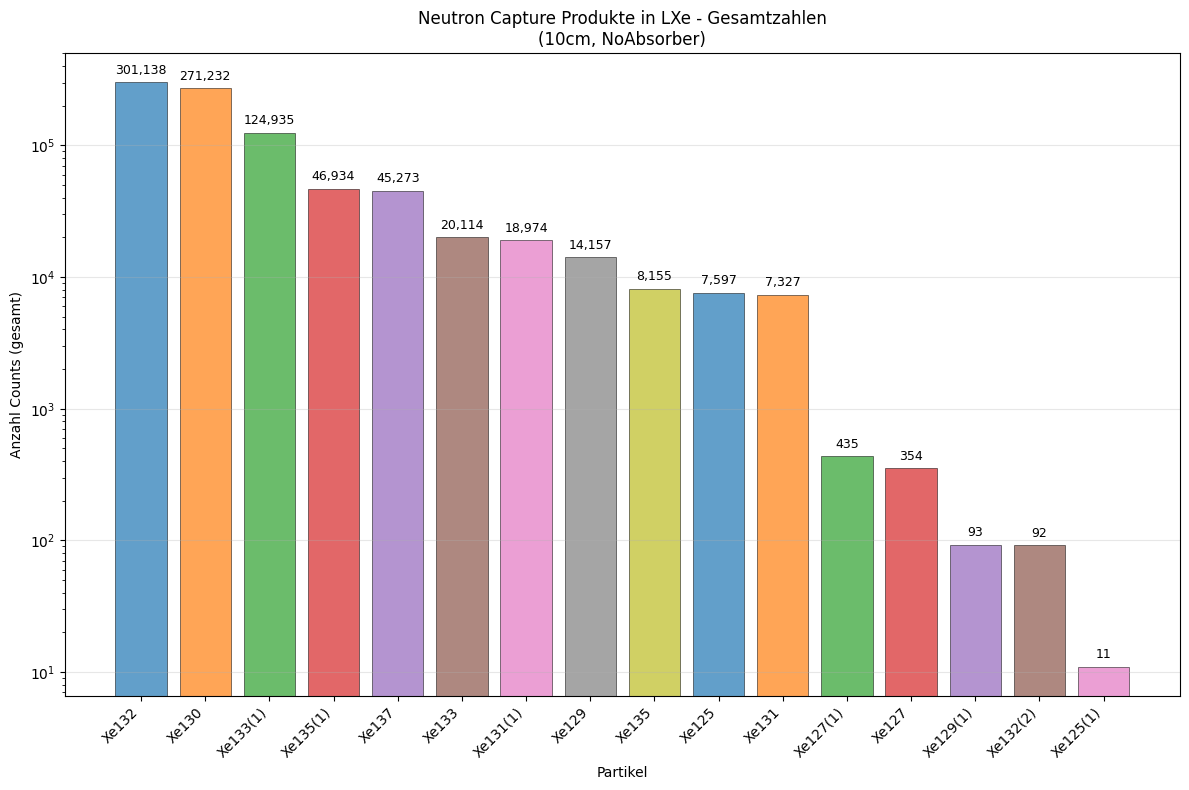


=== PARTIKEL ÜBERSICHT ===
Gesamtanzahl verschiedener Partikel: 16
Gesamtanzahl Events: 866,821

=== TOP 10 PARTIKEL ===
 1. Xe132          :  301,138 counts ( 34.7%)
 2. Xe130          :  271,232 counts ( 31.3%)
 3. Xe133(1)       :  124,935 counts ( 14.4%)
 4. Xe135(1)       :   46,934 counts (  5.4%)
 5. Xe137          :   45,273 counts (  5.2%)
 6. Xe133          :   20,114 counts (  2.3%)
 7. Xe131(1)       :   18,974 counts (  2.2%)
 8. Xe129          :   14,157 counts (  1.6%)
 9. Xe135          :    8,155 counts (  0.9%)
10. Xe125          :    7,597 counts (  0.9%)


In [39]:
# Sortiere Partikel nach Gesamtzahl der Counts
sorted_particles = sorted(histograms.items(), key=lambda x: x[1].sum(), reverse=True)

# Erstelle einfachen Balken-Plot der Gesamtzahlen
plt.figure(figsize=(12, 8))

particle_names = [item[0] for item in sorted_particles]
total_counts = [item[1].sum() for item in sorted_particles]

# Erstelle Balkendiagramm
bars = plt.bar(range(len(particle_names)), total_counts, 
               color=colors[:len(particle_names)], 
               alpha=0.7,
               edgecolor='black', linewidth=0.5)

# Formatierung
plt.xticks(range(len(particle_names)), particle_names, rotation=45, ha='right')
plt.xlabel('Partikel')
plt.ylabel('Anzahl Counts (gesamt)')
plt.title(f'Neutron Capture Produkte in LXe - Gesamtzahlen\n({path_length}, {path_Material})')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

# Zeige Werte auf den Balken
for i, (bar, count) in enumerate(zip(bars, total_counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
             f'{count:,}', ha='center', va='bottom', fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/NC_ParticleCounts.pdf", 
            bbox_inches='tight', dpi=300)
plt.show()

# Zusätzlich: Detaillierte Statistik
print(f"\n=== PARTIKEL ÜBERSICHT ===")
print(f"Gesamtanzahl verschiedener Partikel: {len(histograms)}")
total_all = sum(total_counts)
print(f"Gesamtanzahl Events: {total_all:,}")

print(f"\n=== TOP 10 PARTIKEL ===")
for i, (name, data) in enumerate(sorted_particles[:10]):
    percentage = (data.sum() / total_all) * 100
    print(f"{i+1:2d}. {name:15s}: {data.sum():8,} counts ({percentage:5.1f}%)")


## Mehrere

In [3]:
path_Version = "4_7e82d44"
path_Materials = ["NoAbsorber", 'Polyethylen', 'Polyethylen25']  # NoAbsorber
path_lengths = [["10cm"], ['10cm', '20cm', '30cm', '40cm', '50cm', '60cm'], ['10cm', '20cm', '30cm', '40cm']]

paths = []
for material, lengths in zip(path_Materials, path_lengths):
    paths.append([
        f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{material}/{length}/NC_in_LXe.npz"
        for length in lengths
    ])

for absorber in paths:
    for length in absorber:
        if not os.path.exists(length):
            print(f"Fehler: Pfad {length} existiert nicht.")
            continue


In [4]:
grouped_index = [[None for _ in paths_list] for paths_list in paths]
grouped_data_values = [[None for _ in paths_list] for paths_list in paths]
laenge = [[None for _ in paths_list] for paths_list in paths]
bins = [[None for _ in paths_list] for paths_list in paths]
histograms = [[None for _ in paths_list] for paths_list in paths]

for i, absorber in enumerate(paths):
    for j, length in enumerate(absorber):
        path = length
        grouped_index[i][j] = np.load(path, allow_pickle=True)['grouped_index']
        grouped_data_values[i][j] = np.load(path, allow_pickle=True)['grouped_data']
        laenge[i][j] = np.load(path, allow_pickle=True)['laenge']
        bins[i][j] = np.load(path, allow_pickle=True)['bins']

        histograms[i][j] = {name: data for name, data in zip(grouped_index[i][j], grouped_data_values[i][j])}


In [5]:
# kombiniert alle isotope von den jeweiligen konfigurationen
hist_comb = [[None for _ in range(len(histograms[i]))] for i in range(len(histograms))]

for i in range(len(histograms)):
    for j in range(len(histograms[i])):
        # Alle Histogramme (Werte) addieren
        all_hist = list(histograms[i][j].values())
        # Annahme: alle Histogramme sind gleich groß (z.B. 249 bins)
        hist_sum = np.sum(all_hist, axis=0)
        hist_comb[i][j] = hist_sum

In [6]:
# Normiert die histogramme auf die simulierte anzahl an neutronen
histograms_normalized = [[None for _ in range(len(hist_comb[i]))] for i in range(len(hist_comb))]

for i in range(len(histograms_normalized)):
    for j in range(len(histograms_normalized[i])):
        histograms_normalized[i][j] = hist_comb[i][j] / laenge[i][j] * 100

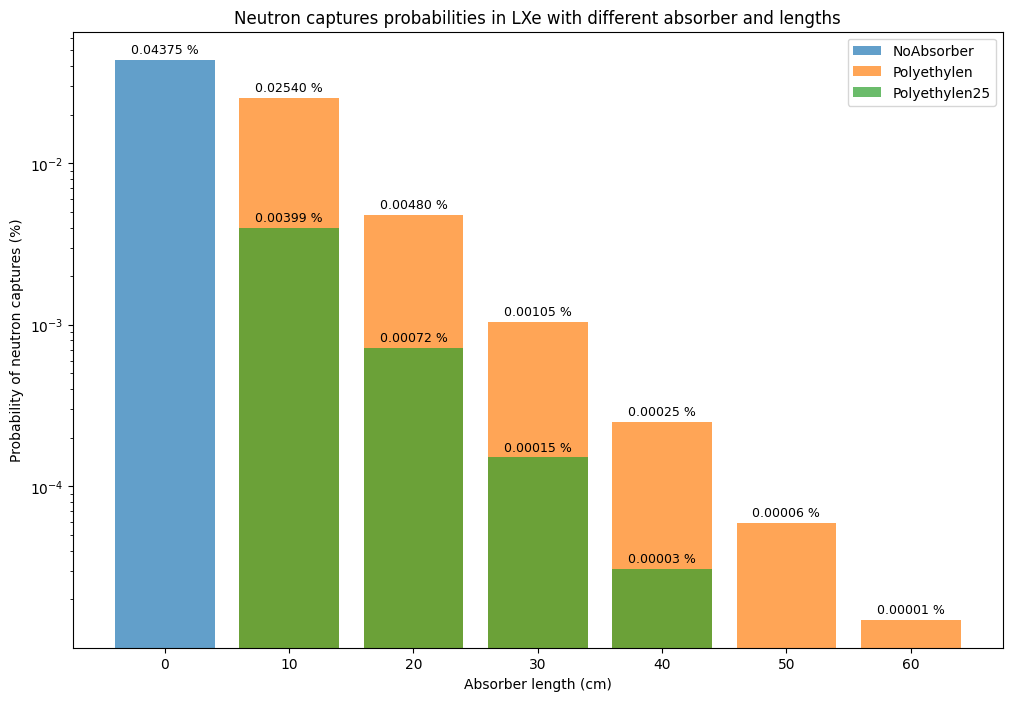

In [8]:
x = [[0],[10,20,30,40,50,60], [10,20,30,40]]
y = [[sum(histograms_normalized[i][j]) for j in range(len(histograms_normalized[i]))] for i in range(len(histograms_normalized))]

plt.figure(figsize=(12, 8))
for i, absorber in enumerate(paths):
    bars = plt.bar(x[i], y[i], width=8, alpha=0.7, 
                   label=f'{absorber[0].split("/")[-3]}')
    
    # Füge Text auf jeden Balken hinzu
    for j, (bar, value) in enumerate(zip(bars, y[i])):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, 
                 f'{value:.5f} %', ha='center', va='bottom', fontsize=9, rotation=0)

plt.xlabel('Absorber length (cm)')
plt.ylabel('Probability of neutron captures (%)')
plt.yscale('log')
plt.title(f'Neutron captures probabilities in LXe with different absorber and lengths')
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/comparison.pdf")
plt.show()

# Einzelplots

In [8]:
path_Version = "4_7e82d44"
path_Material = "NoAbsorber"  # NoAbsorber
path_length = "10cm"

print(f"Konfiguration: {path_Version}, {path_Material}, {path_length}")

Konfiguration: 4_7e82d44, NoAbsorber, 10cm


In [9]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

In [10]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic', 'CoulombScat']
volumes = ['e_pri', 'Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## NC Energydependent


### In Liquid Xenon

In [11]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.npz"
hist_vals = np.load(path, allow_pickle=True)['hist_vals']
hist_edges = np.load(path, allow_pickle=True)['hist_edges']
hist_pri_vals = np.load(path, allow_pickle=True)['hist_pri_vals']
hist_pri_edges = np.load(path, allow_pickle=True)['hist_pri_edges']

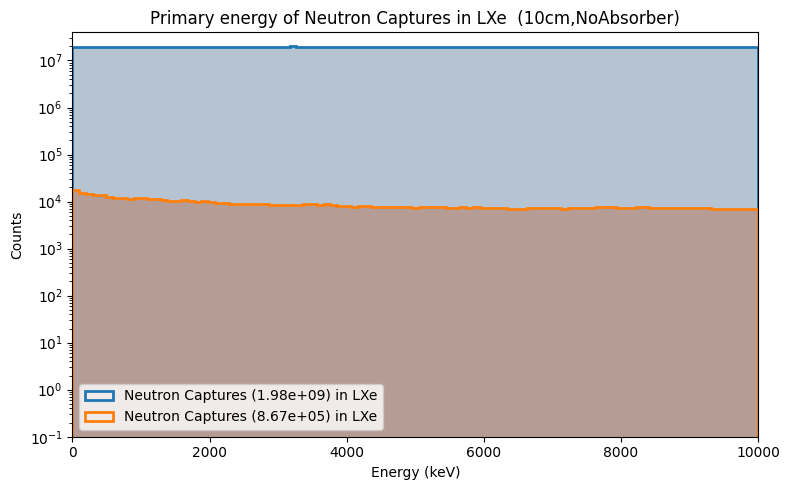

In [12]:
plt.figure(figsize=(8, 5))
""" plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
) """
plt.hist(
    hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
    histtype='step', color=colors[0], alpha=1, linewidth=2,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)
plt.hist(
    hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
    histtype='stepfilled', color=edge_colors[0], alpha=0.3,
)

plt.hist(
    hist_edges[:-1], bins=hist_edges, weights=hist_vals,
    histtype='step', color=colors[1], alpha=1, linewidth=2,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.hist(
    hist_edges[:-1], bins=hist_edges, weights=hist_vals,
    histtype='stepfilled', color=edge_colors[1], alpha=0.3, 
)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in LXe  ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.pdf")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.png")
plt.show()

In [7]:
len(hist_vals)

101

### In Absorber

In [14]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.npz"
hist_vals = np.load(path, allow_pickle=True)['hist_vals']
hist_edges = np.load(path, allow_pickle=True)['hist_edges']
hist_pri_vals = np.load(path, allow_pickle=True)['hist_pri_vals']
hist_pri_edges = np.load(path, allow_pickle=True)['hist_pri_edges']

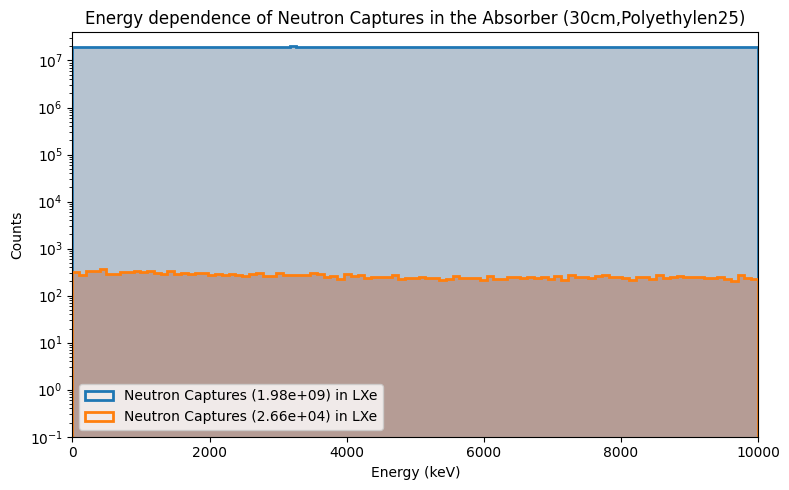

In [15]:
plt.figure(figsize=(8, 5))
""" plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
) """
plt.hist(
    hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
    histtype='step', color=colors[0], alpha=1, linewidth=2,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)
plt.hist(
    hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
    histtype='stepfilled', color=edge_colors[0], alpha=0.3,
)

plt.hist(
    hist_edges[:-1], bins=hist_edges, weights=hist_vals,
    histtype='step', color=colors[1], alpha=1, linewidth=2,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.hist(
    hist_edges[:-1], bins=hist_edges, weights=hist_vals,
    histtype='stepfilled', color=edge_colors[1], alpha=0.3, 
)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Energy dependence of Neutron Captures in the Absorber ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.png")
plt.show()

## Processes

### Xenon Volume

In [16]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_LXe.npz"
grouped_data = np.load(path, allow_pickle=True)['grouped_data_values']
index_level0 = np.load(path, allow_pickle=True)['grouped_data_index_level0']
index_level1 = np.load(path, allow_pickle=True)['grouped_data_index_level1']

In [17]:
grouped_data_series = pd.Series(
    grouped_data, 
    index=pd.MultiIndex.from_arrays([index_level0, index_level1])
)

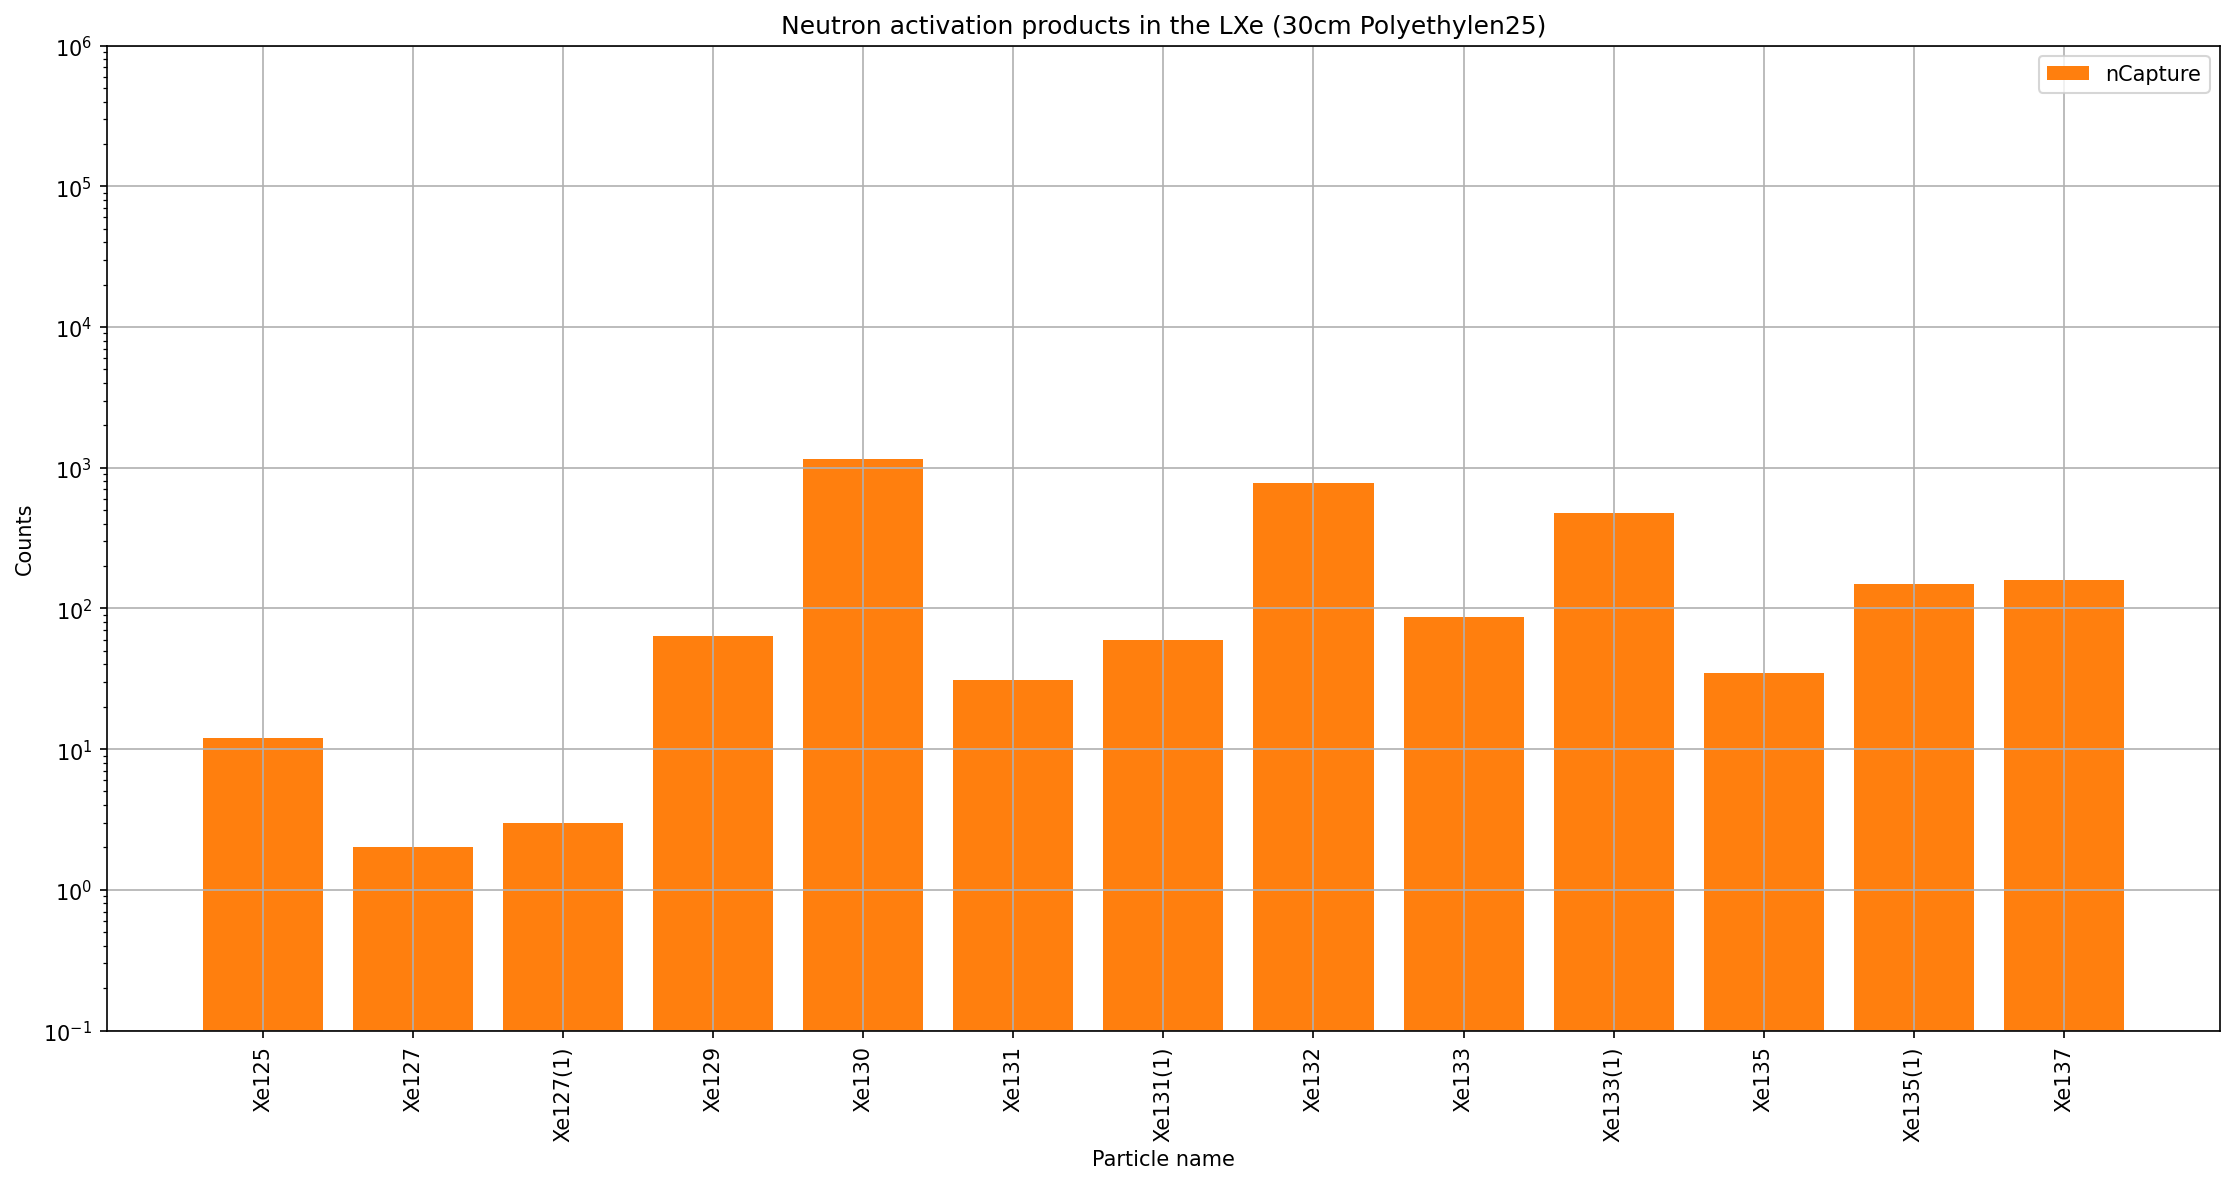

In [18]:
_data = grouped_data_series#[grouped_data.values > 40]

_particles = np.unique(index_level0)
_processes = np.unique(index_level1)

def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0
    
_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))
color = {pr: colors[idx % len(colors)] for idx, pr in enumerate(_processes_sorted)}


plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the LXe ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e6)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.png" )
plt.tight_layout()
plt.grid()

plt.show()




### Absorber Volume

In [19]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.npz"
grouped_data = np.load(path, allow_pickle=True)['grouped_data_values']
index_level0 = np.load(path, allow_pickle=True)['grouped_data_index_level0']
index_level1 = np.load(path, allow_pickle=True)['grouped_data_index_level1']

In [20]:
grouped_data_series = pd.Series(
    grouped_data, 
    index=pd.MultiIndex.from_arrays([index_level0, index_level1])
)

0
1
2
3
4
5


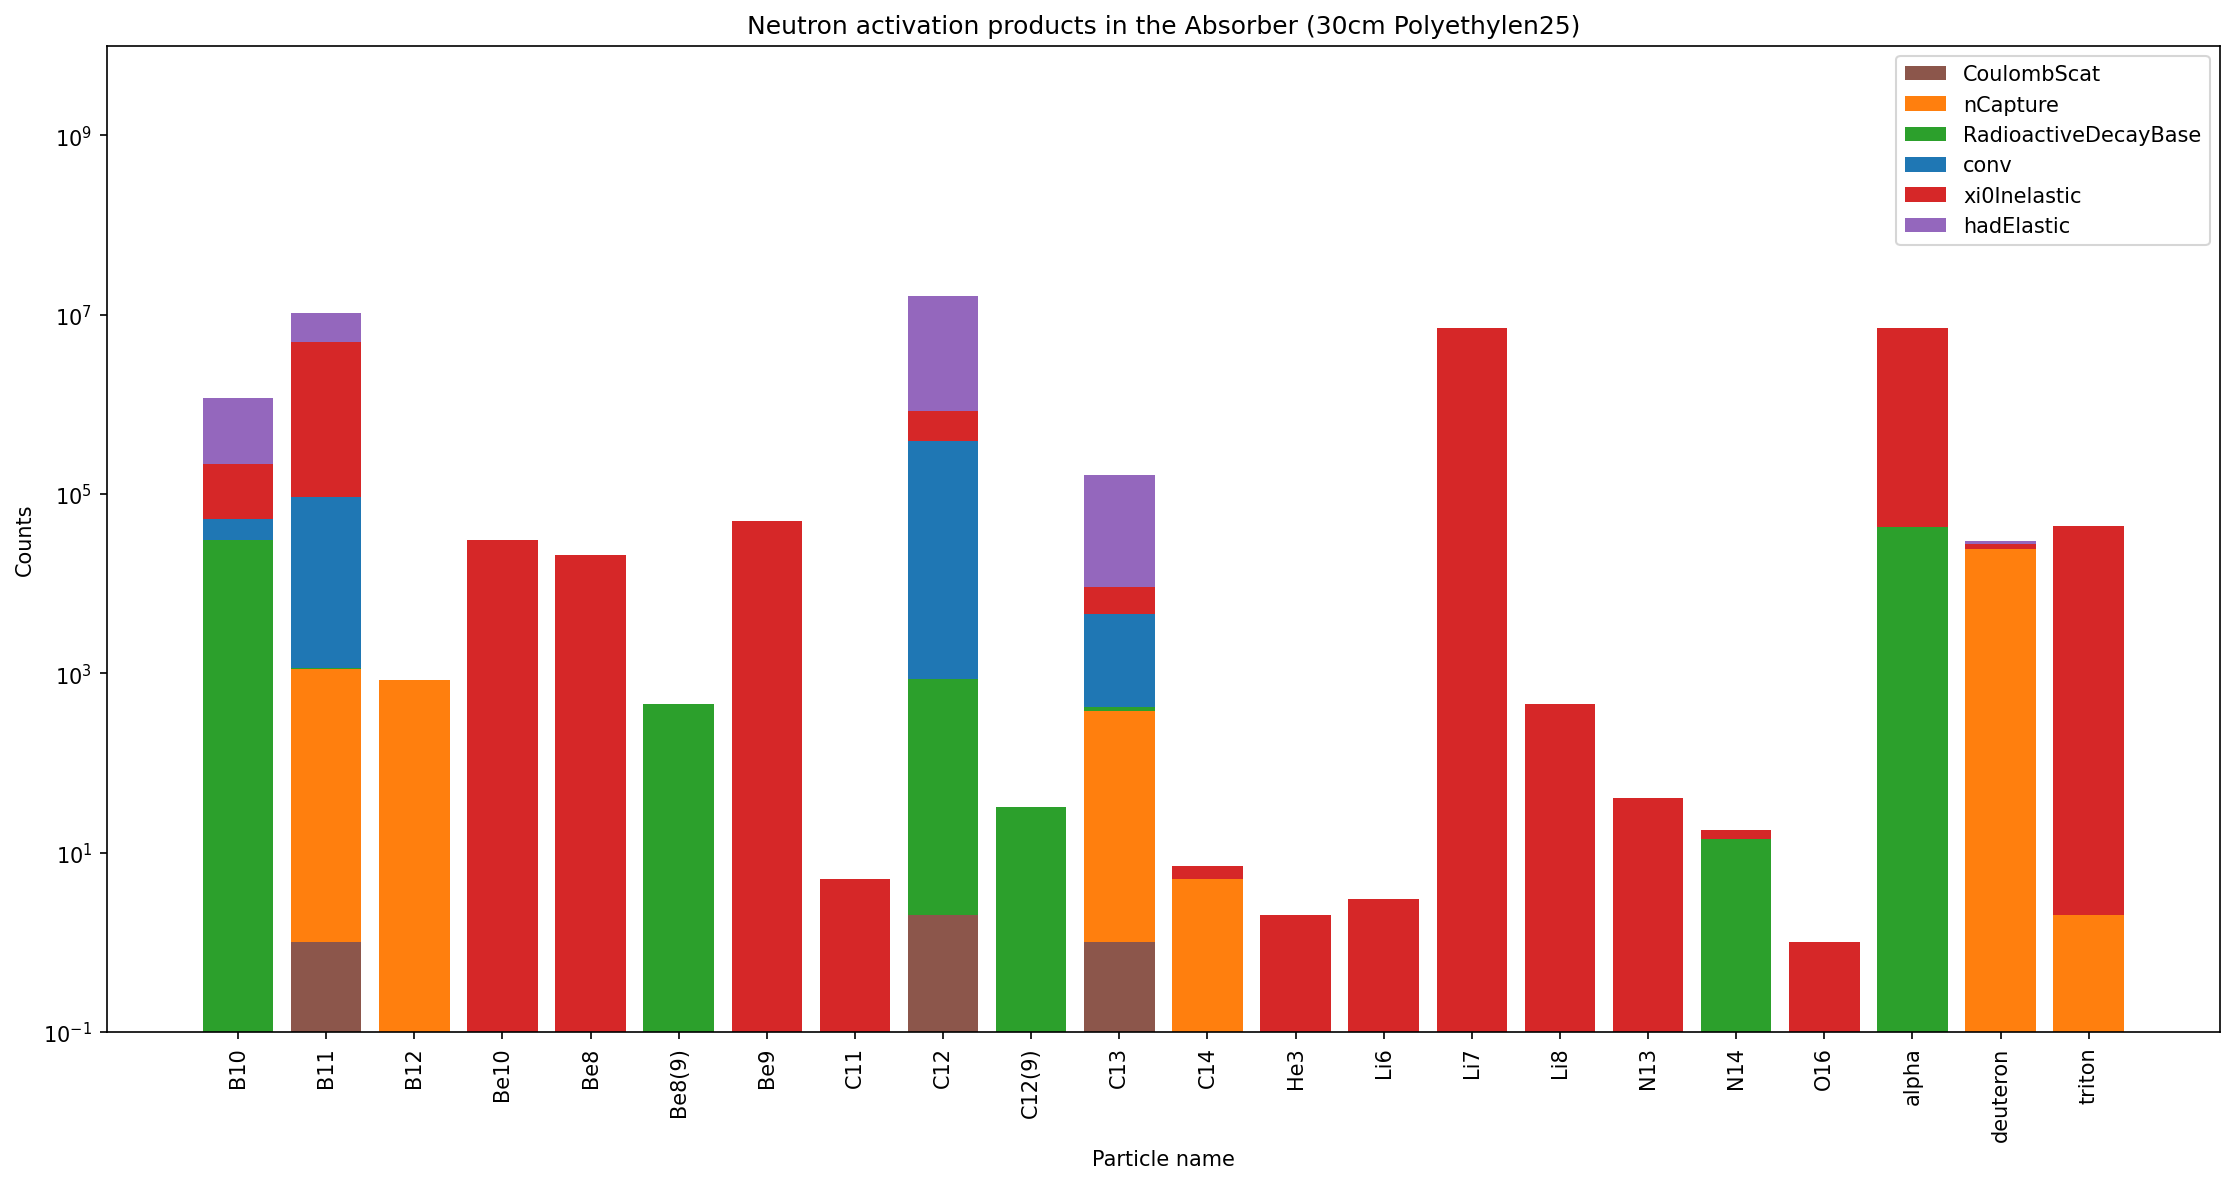

In [21]:
_data = grouped_data_series#[grouped_data.values > 40]
#_data = grouped_data

_particles = np.unique(index_level0)
_processes = np.unique(index_level1)



def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0

_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))

plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    print(idx)
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e10)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.png" )
plt.tight_layout()
plt.show()



## Energy Distributions trend

In [22]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.npz"
hist_vals_list = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list = np.load(path, allow_pickle=True)['bin_edges_list']
labels = np.load(path, allow_pickle=True)['labels']
labels

FileNotFoundError: [Errno 2] No such file or directory: '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/4_7e82d44/Polyethylen25/30cm/EnergyDistributions_Volumes.npz'

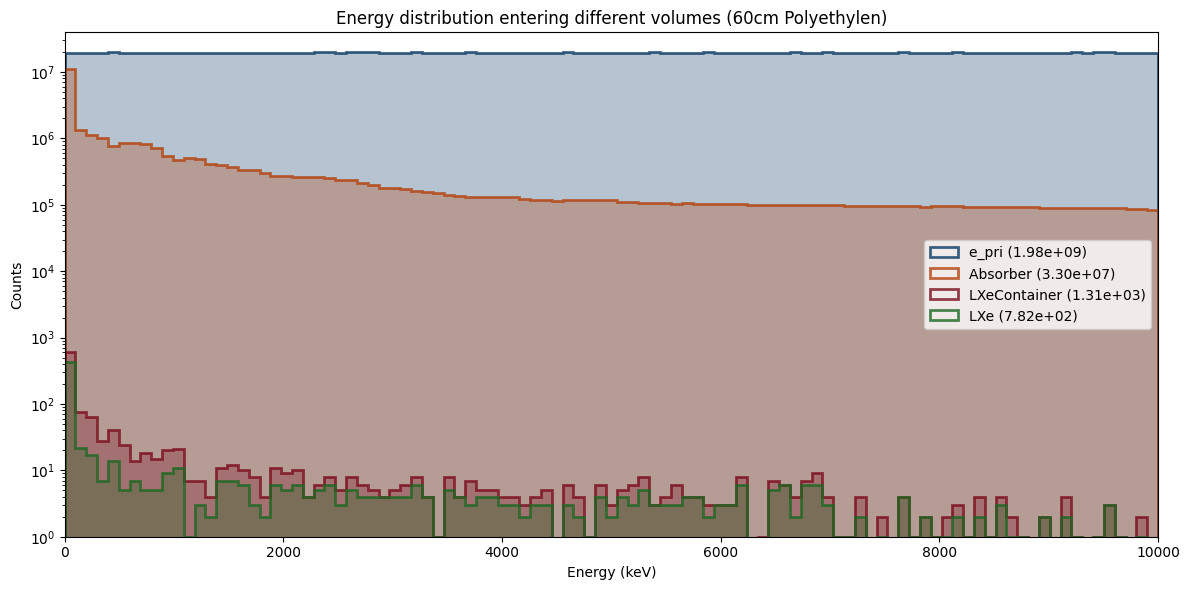

In [ ]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)

maxi = max(hist_vals_list[0].max(), hist_vals_list[1].max(), hist_vals_list[2].max(), hist_vals_list[3].max())

for i in all_indices_sorted:
    # Use colors_Volumes and volumes only for indices 1,2,3 (since volumes has length 3)
    bar_color = colors_Volumes[labels[i]]
    bar_edge_color = colors_edges[labels[i]]
    # Use bar_edge_color safely
    plt.hist(bin_edges_list[i][:-1], bins=bin_edges_list[i], weights=hist_vals_list[i],
            histtype='step', linewidth=2, color=bar_edge_color,
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})', alpha=0.8)
    
    plt.hist(bin_edges_list[i][:-1], bins=bin_edges_list[i], weights=hist_vals_list[i],
            histtype='stepfilled', color=bar_color, alpha=0.3)

plt.xlim(0, 10000)

plt.yscale('log')
plt.ylim(1,maxi * 2)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.png" )
plt.show()

## Positions

### 2D

In [ ]:
# Nur 1/10 der daten
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Positions.npz"
h3d_computed = np.load(path, allow_pickle=True)['h3d_computed']
coords = np.load(path, allow_pickle=True)['coords']
ranges = np.load(path, allow_pickle=True)['ranges']
bins_all = np.load(path, allow_pickle=True)['bins_all']


In [ ]:
# Erstelle boost_histogram Objekte aus deinen Daten
boost_histograms = []

for i, hist_data in enumerate(h3d_computed):
    # Erstelle Achsen basierend auf deinen ranges und bins
    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]
    
    # Erstelle boost_histogram
    hist = bh.Histogram(
        bh.axis.Regular(x_bins, x_range[0], x_range[1]),
        bh.axis.Regular(y_bins, y_range[0], y_range[1]), 
        bh.axis.Regular(z_bins, z_range[0], z_range[1])
    )
    
    # Fülle mit deinen Daten
    hist[...] = hist_data
    
    boost_histograms.append(hist)

print(f"Erstellt {len(boost_histograms)} boost_histogram Objekte")

h3d_computed = [hist for hist in boost_histograms]

Erstellt 3 boost_histogram Objekte


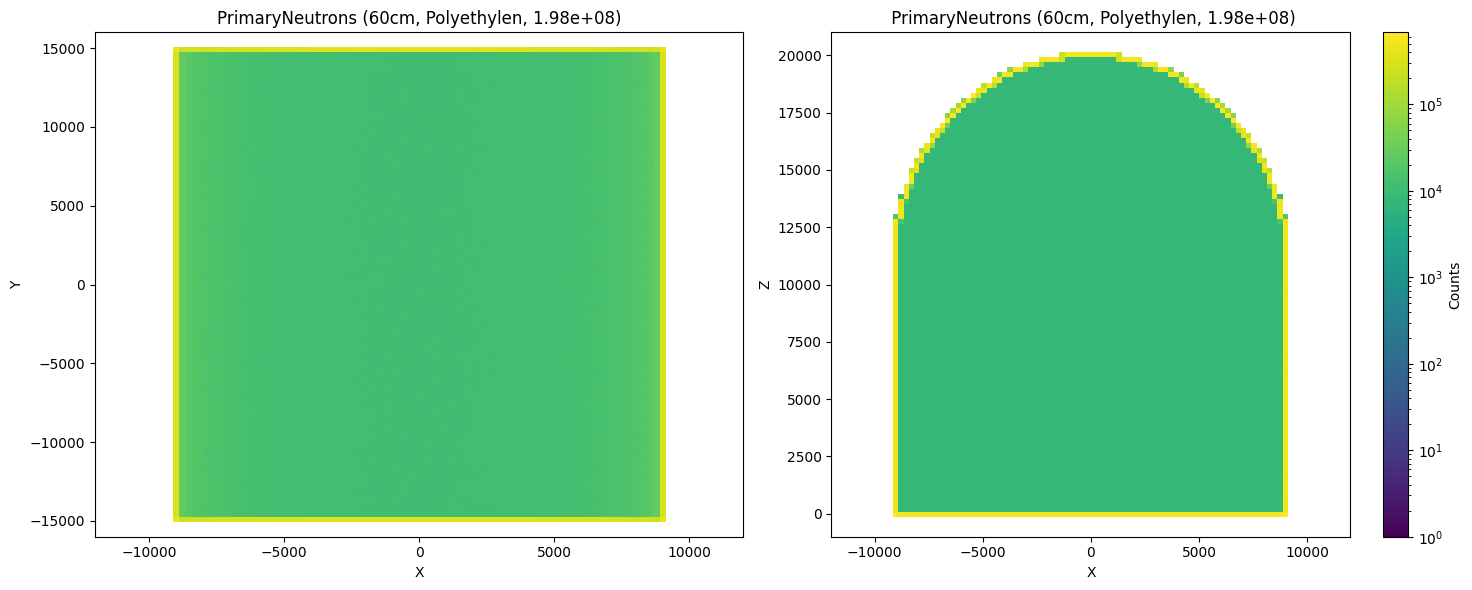

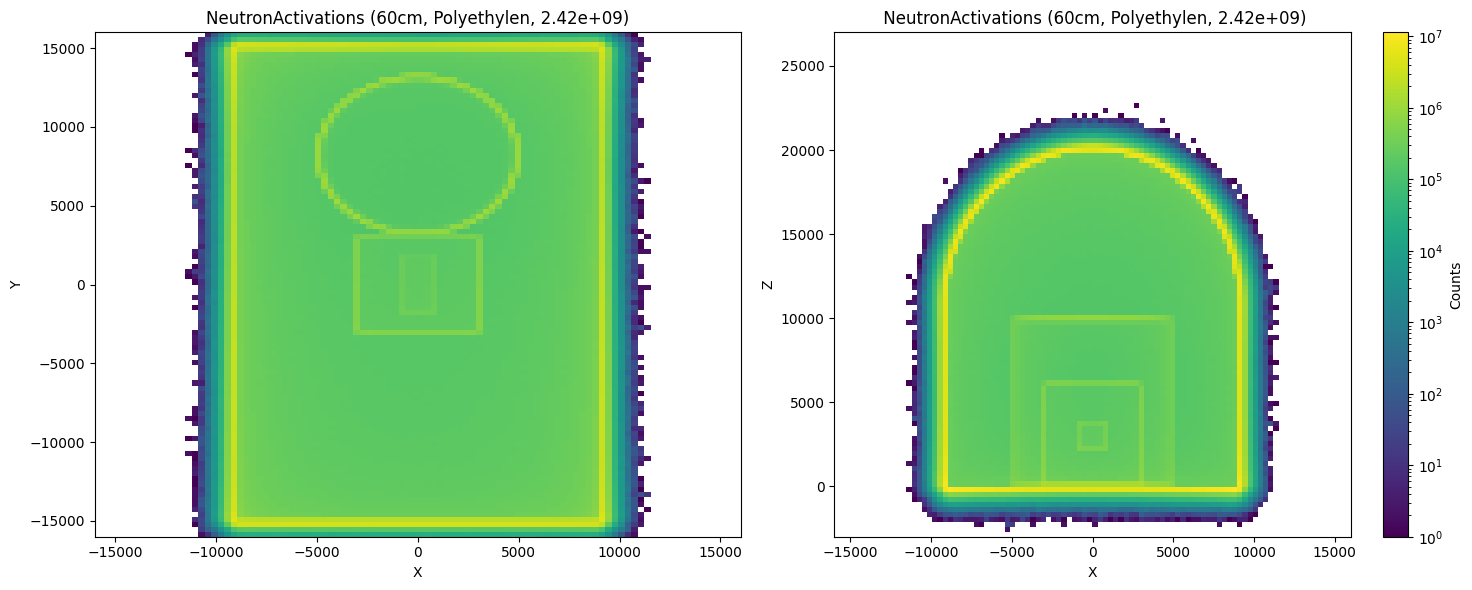

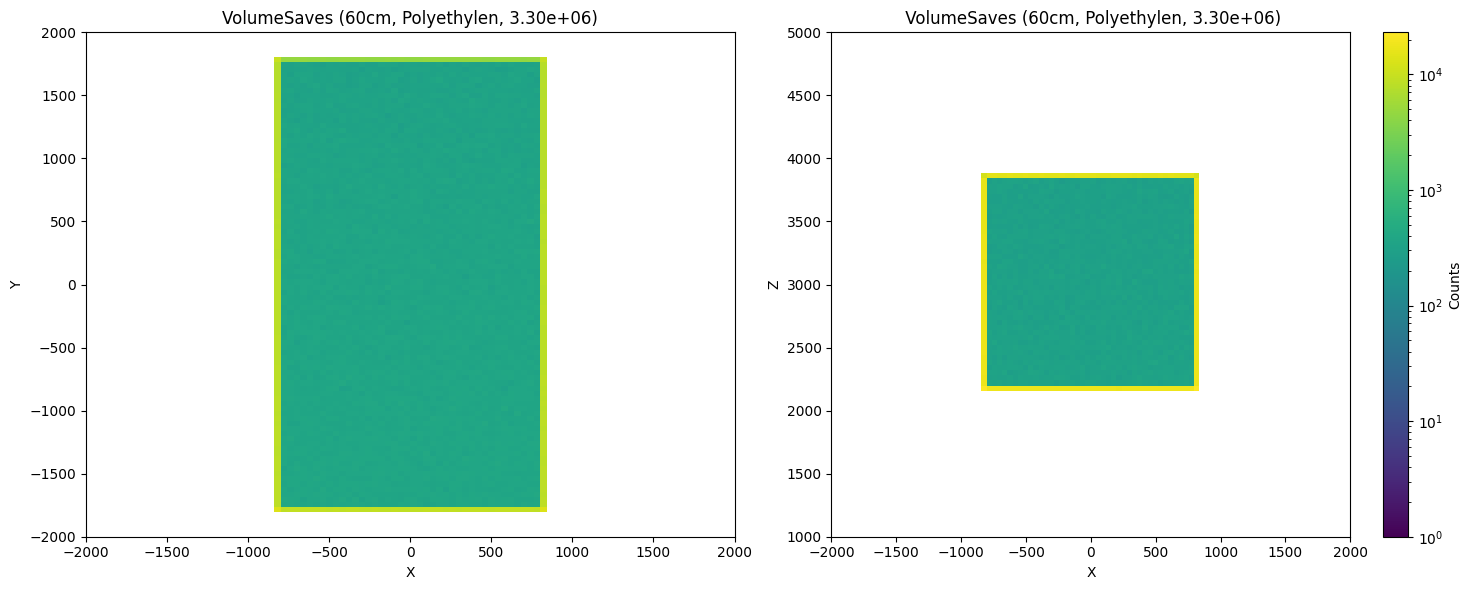

In [ ]:
grid = False

for i,coord in enumerate(coords):
    if i == 0:
        a='PrimaryNeutrons'
    elif i == 1:
        a='NeutronActivations'
    elif i == 2:
        a='VolumeSaves'

    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]

    xy_proj = h3d_computed[i][:,:,sum].view()
    xz_proj = h3d_computed[i][:,sum,:].view()
    max_val = max(xy_proj.max(), xz_proj.max())
    all = h3d_computed[i].sum()

    fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

    aspect = 'auto'

    norm = mpl.colors.LogNorm(vmin=1, vmax=max_val) 
    #norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.1)  # Use Normalize for linear scaling
    #aspect = 'equal'

    ax[0].imshow(
        xy_proj.T,  
        extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title(f'{a} ({path_length}, {path_Material}, {all:.2e})')



    # XZ-Projektion (Summe über y)
    ax[1].imshow(
        xz_proj.view().T,
        extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Z')
    ax[1].set_title(f' {a} ({path_length}, {path_Material}, {all:.2e})')

    if grid:
        ax[0].minorticks_on()
        ax[0].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[0].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')
        ax[1].minorticks_on()
        ax[1].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[1].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')

    fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
    plt.tight_layout()

    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Positions_{a}.pdf" )
    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Positions_{a}.png" )
    plt.show()

***
# Multiple

In [45]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/all'):
    os.makedirs(f'{pictures_path}/{path_Version}/all')

In [46]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic', 'CoulombScat']
volumes = ['e_pri', 'Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## NC Energydependent


### In Liquid Xenon

In [62]:
files = glob.glob(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/*/*/EnergyNC_LXe.npz")

path_version = [None] * len(files)
path_material = [None] * len(files)
path_length = [None] * len(files)

for i, f in enumerate(files):
    # Beispielpfad: .../Data/4_7e82d44/Polyethylen/10cm/EnergyNC_LXe.npz
    ordner = os.path.dirname(f)  # .../Data/4_7e82d44/Polyethylen/10cm
    path_version[i], path_material[i], path_length[i] = ordner.split("/")[-3:]  # Die letzten 3 Ordner
    print(f"Material: {path_material[i]}, Länge: {path_length[i]}")

Material: NoAbsorber, Länge: 10cm
Material: Polyethylen, Länge: 30cm
Material: Polyethylen, Länge: 40cm
Material: Polyethylen, Länge: 20cm
Material: Polyethylen, Länge: 10cm
Material: Polyethylen, Länge: 50cm


In [63]:
hist_vals_list = []
hist_edges_list = []
for i, f in enumerate(files):
    if i == 0:
        hist_pri_vals = np.load(f, allow_pickle=True)['hist_pri_vals']
        hist_pri_edges = np.load(f, allow_pickle=True)['hist_pri_edges']
        
    hist_vals = np.load(f, allow_pickle=True)['hist_vals']
    hist_edges = np.load(f, allow_pickle=True)['hist_edges']

    hist_vals_list.append(hist_vals)
    hist_edges_list.append(hist_edges)

In [64]:
# Sortiere die files nach der Summe der Histogrammwerte in hist_vals_list
all_indices = [
    i for i in range(len(hist_vals_list))
]

all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)

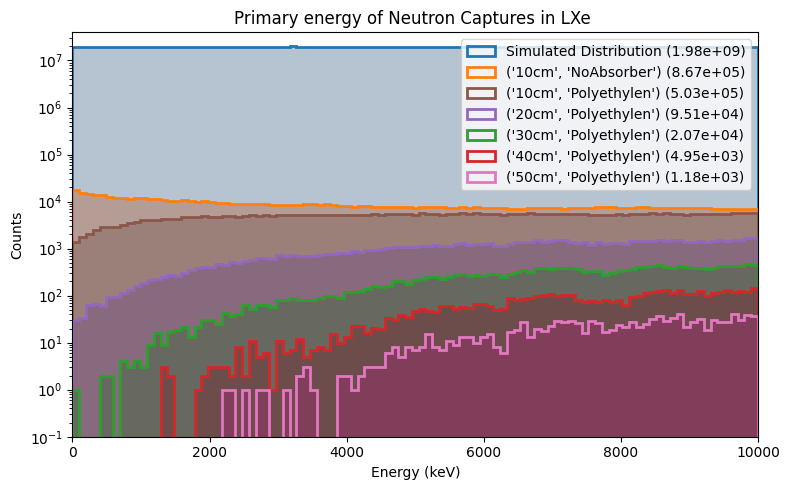

In [65]:
plt.figure(figsize=(8, 5))

for i in all_indices_sorted:
    if i == 0:
        plt.hist(
        hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
        histtype='step', color=colors[0], alpha=1, linewidth=2,
        label=f'Simulated Distribution ({hist_pri_vals.sum():.2e})'
        )
        plt.hist(
            hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
            histtype='stepfilled', color=edge_colors[0], alpha=0.3,
        )
        

    plt.hist(
        hist_edges_list[i][:-1], bins=hist_edges_list[i], weights=hist_vals_list[i],
        histtype='step', color=colors[i+1], alpha=1, linewidth=2,
        label=f'{path_length[i], path_material[i]} ({hist_vals_list[i].sum():.2e})'
    )
    plt.hist(
        hist_edges_list[i][:-1], bins=hist_edges_list[i], weights=hist_vals_list[i],
        histtype='stepfilled', color=edge_colors[i+1], alpha=0.3,
    )

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in LXe ')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/EnergyNC_LXe.pdf")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/EnergyNC_LXe.png")
plt.show()

### In Absorber

In [83]:
files = glob.glob(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/*/*/EnergyNC_Absorber.npz")

path_version = [None] * len(files)
path_material = [None] * len(files)
path_length = [None] * len(files)

for i, f in enumerate(files):
    # Beispielpfad: .../Data/4_7e82d44/Polyethylen/10cm/EnergyNC_LXe.npz
    ordner = os.path.dirname(f)  # .../Data/4_7e82d44/Polyethylen/10cm
    path_version[i], path_material[i], path_length[i] = ordner.split("/")[-3:]  # Die letzten 3 Ordner
    print(f"Material: {path_material[i]}, Länge: {path_length[i]}")

Material: NoAbsorber, Länge: 10cm
Material: Polyethylen, Länge: 30cm
Material: Polyethylen, Länge: 40cm
Material: Polyethylen, Länge: 20cm
Material: Polyethylen, Länge: 10cm
Material: Polyethylen, Länge: 50cm


In [84]:
hist_vals_list = []
hist_edges_list = []

for i, f in enumerate(files):
    if i == 0:
        hist_pri_vals = np.load(f, allow_pickle=True)['hist_pri_vals']
        hist_pri_edges = np.load(f, allow_pickle=True)['hist_pri_edges']
        
    hist_vals = np.load(f, allow_pickle=True)['hist_vals']
    hist_edges = np.load(f, allow_pickle=True)['hist_edges']

    hist_vals_list.append(hist_vals)
    hist_edges_list.append(hist_edges)

In [85]:
# Sortiere die files nach der Summe der Histogrammwerte in hist_vals_list
all_indices = [
    i for i in range(len(hist_vals_list))
]

all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)


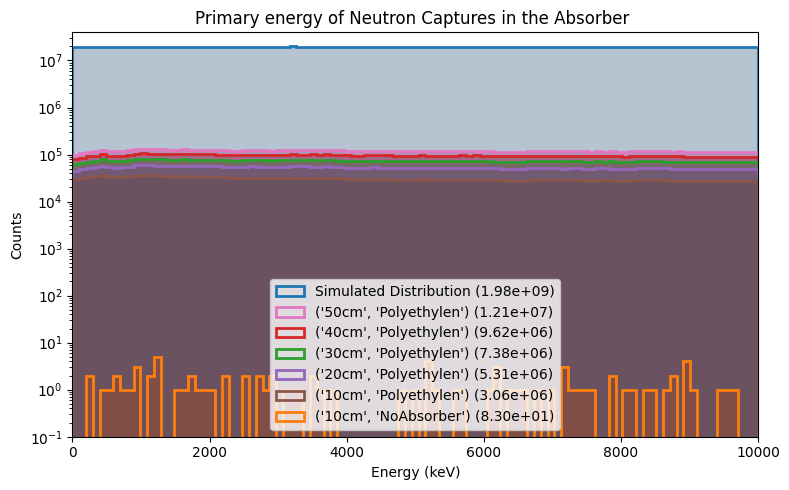

In [86]:
plt.figure(figsize=(8, 5))

plt.hist(
    hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
    histtype='step', color=colors[0], alpha=1, linewidth=2,
    label=f'Simulated Distribution ({hist_pri_vals.sum():.2e})'
)
plt.hist(
    hist_pri_edges[:-1], bins=hist_pri_edges, weights=hist_pri_vals,
    histtype='stepfilled', color=edge_colors[0], alpha=0.3,
)

for i in all_indices_sorted:
    plt.hist(
        hist_edges_list[i][:-1], bins=hist_edges_list[i], weights=hist_vals_list[i],
        histtype='step', color=colors[i+1], alpha=1, linewidth=2,
        label=f'{path_length[i], path_material[i]} ({hist_vals_list[i].sum():.2e})'
    )
    plt.hist(
        hist_edges_list[i][:-1], bins=hist_edges_list[i], weights=hist_vals_list[i],
        histtype='stepfilled', color=edge_colors[i+1], alpha=0.3,
    )

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in the Absorber ')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/EnergyNC_Absorber.pdf")
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/all/EnergyNC_Absorber.png")
plt.show()

## Processes

### Xenon Volume

In [ ]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_LXe.npz"
grouped_data = np.load(path, allow_pickle=True)['grouped_data_values']
index_level0 = np.load(path, allow_pickle=True)['grouped_data_index_level0']
index_level1 = np.load(path, allow_pickle=True)['grouped_data_index_level1']

In [ ]:
grouped_data_series = pd.Series(
    grouped_data, 
    index=pd.MultiIndex.from_arrays([index_level0, index_level1])
)

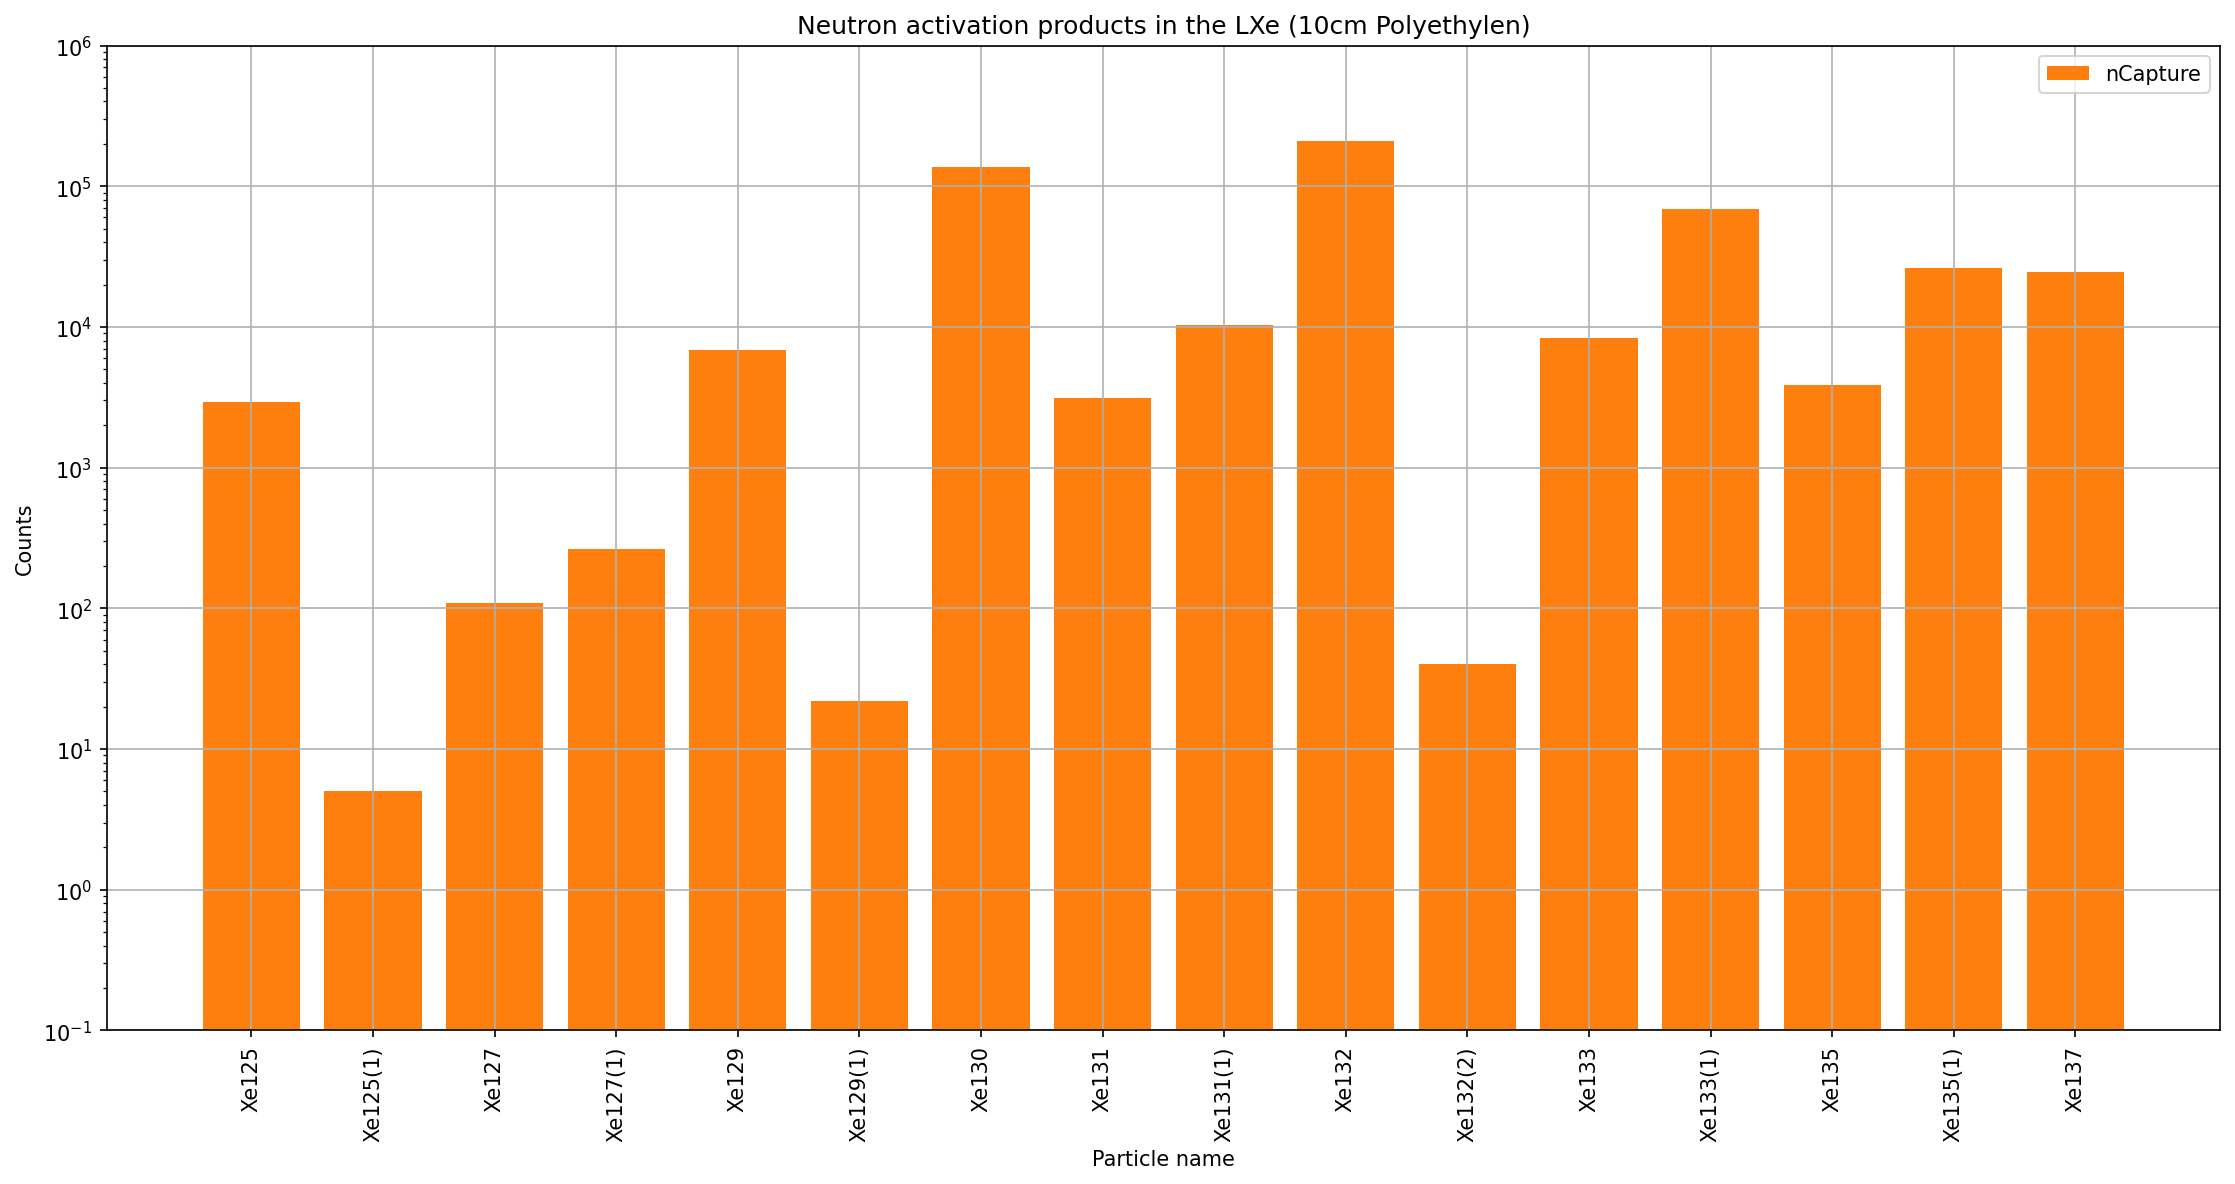

In [ ]:
_data = grouped_data_series#[grouped_data.values > 40]

_particles = np.unique(index_level0)
_processes = np.unique(index_level1)

def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0
    
_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))
color = {pr: colors[idx % len(colors)] for idx, pr in enumerate(_processes_sorted)}


plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the LXe ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e6)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.png" )
plt.tight_layout()
plt.grid()

plt.show()




### Absorber Volume

In [ ]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.npz"
grouped_data = np.load(path, allow_pickle=True)['grouped_data_values']
index_level0 = np.load(path, allow_pickle=True)['grouped_data_index_level0']
index_level1 = np.load(path, allow_pickle=True)['grouped_data_index_level1']

In [ ]:
grouped_data_series = pd.Series(
    grouped_data, 
    index=pd.MultiIndex.from_arrays([index_level0, index_level1])
)

0
1
2
3
4


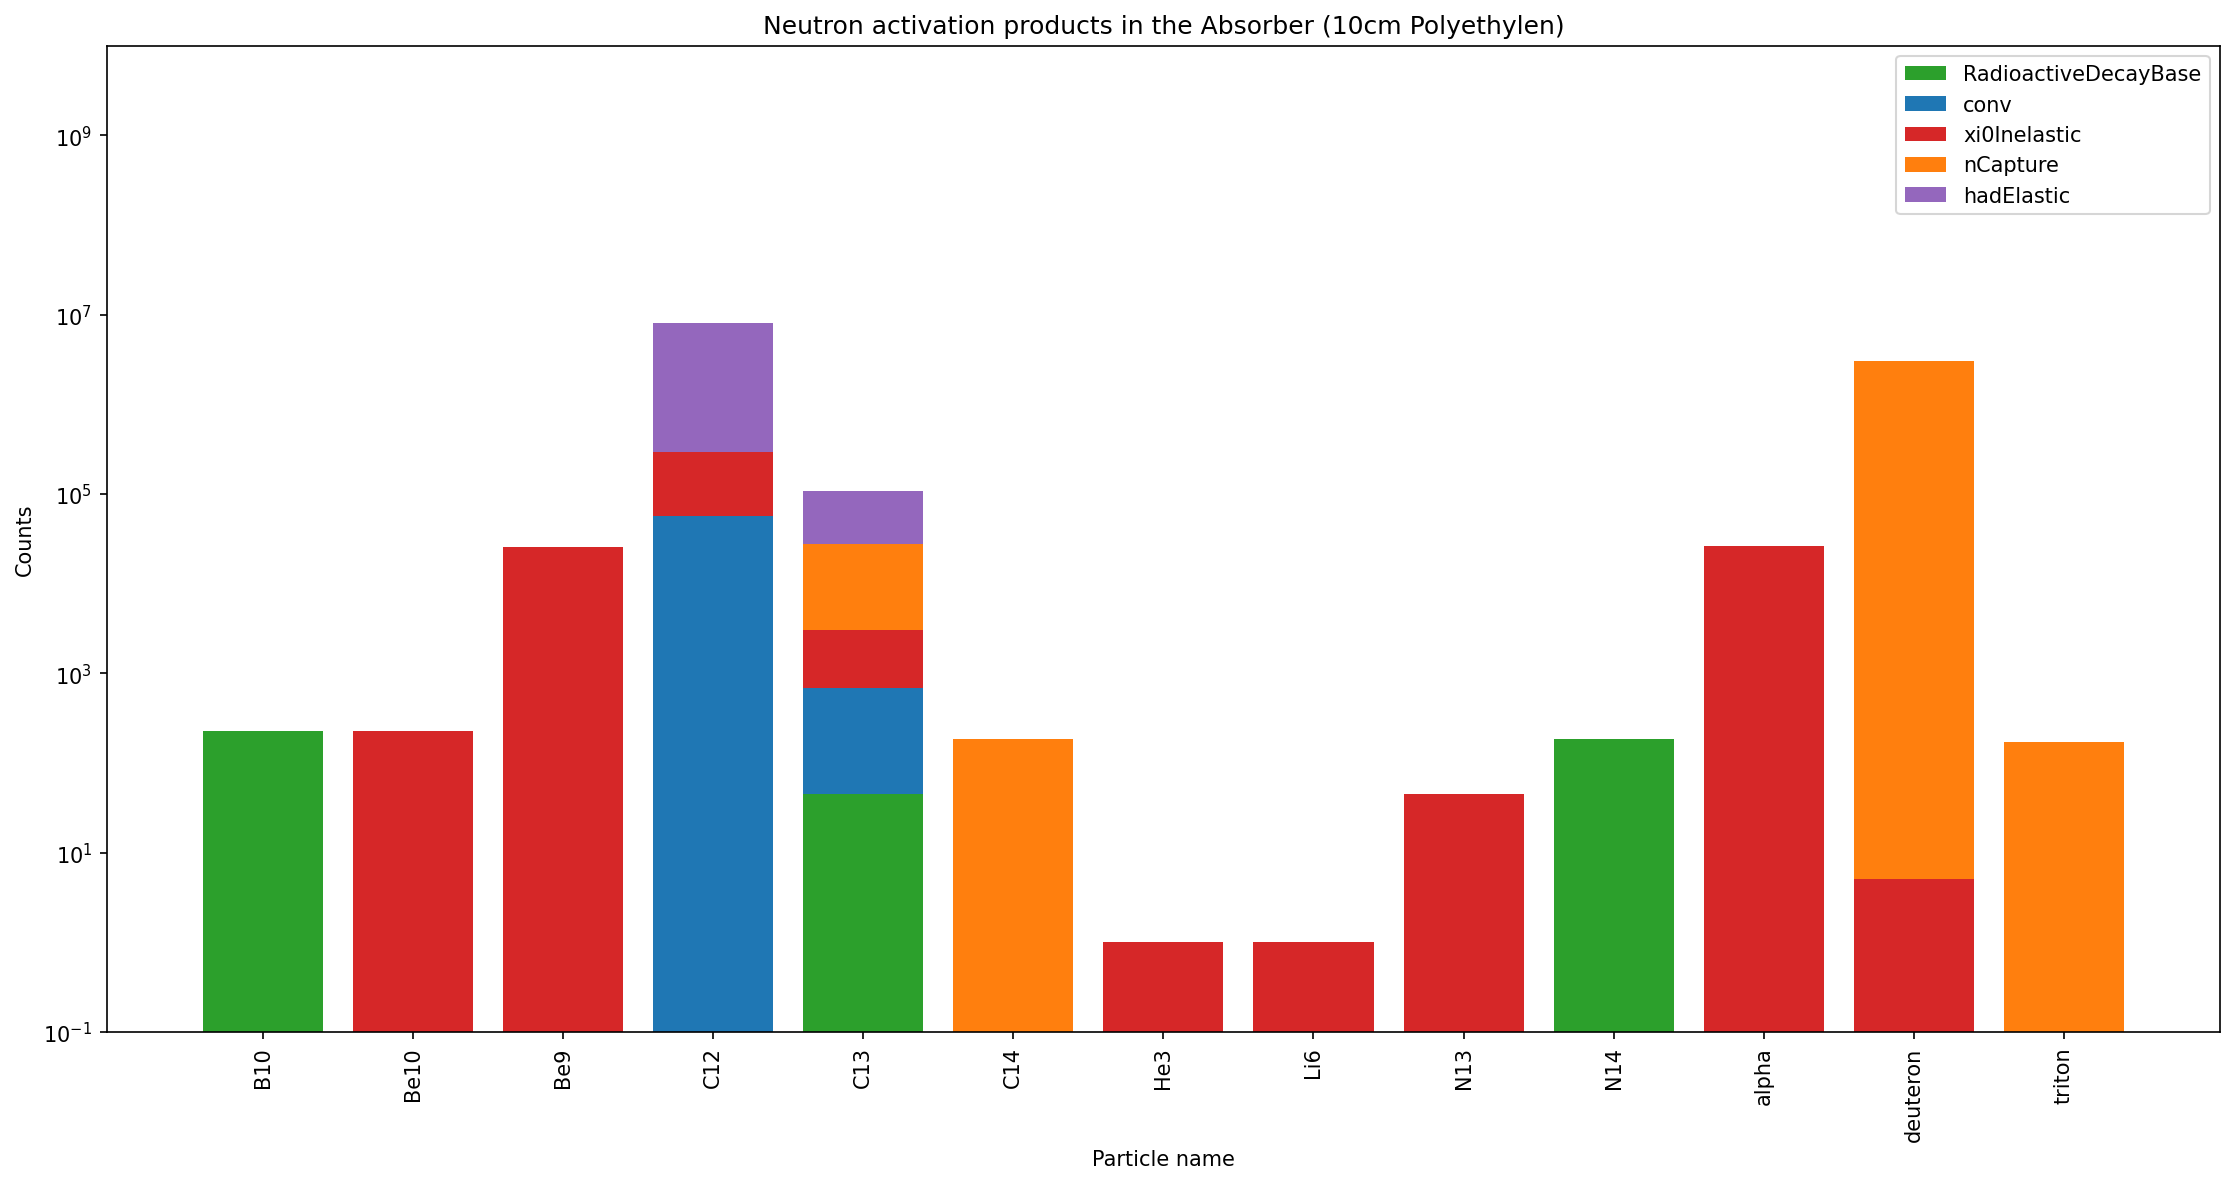

In [ ]:
_data = grouped_data_series#[grouped_data.values > 40]
#_data = grouped_data

_particles = np.unique(index_level0)
_processes = np.unique(index_level1)



def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0

_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))

plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    print(idx)
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e10)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.png" )
plt.tight_layout()
plt.show()



In [ ]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.npz"
hist_vals_list = np.load(path, allow_pickle=True)['hist_vals_list']
bin_edges_list = np.load(path, allow_pickle=True)['bin_edges_list']
labels = np.load(path, allow_pickle=True)['labels']
labels

array(['e_pri', 'Absorber', 'LXe', 'LXeContainer'], dtype='<U12')

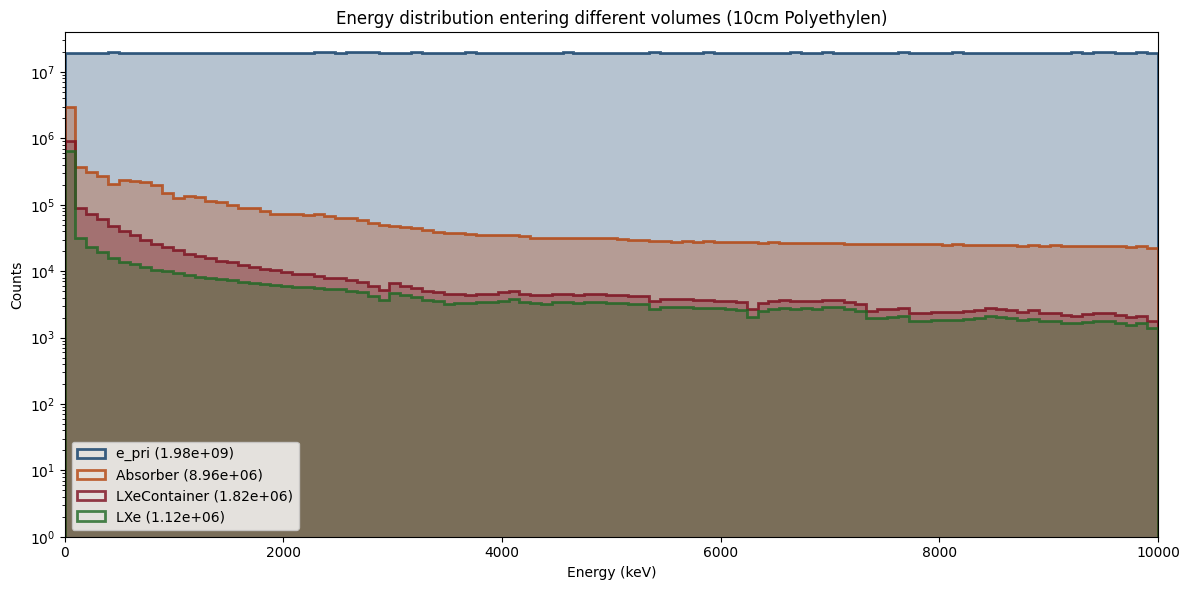

In [ ]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)

maxi = max(hist_vals_list[0].max(), hist_vals_list[1].max(), hist_vals_list[2].max(), hist_vals_list[3].max())

for i in all_indices_sorted:
    # Use colors_Volumes and volumes only for indices 1,2,3 (since volumes has length 3)
    bar_color = colors_Volumes[labels[i]]
    bar_edge_color = colors_edges[labels[i]]
    # Use bar_edge_color safely
    plt.hist(bin_edges_list[i][:-1], bins=bin_edges_list[i], weights=hist_vals_list[i],
            histtype='step', linewidth=2, color=bar_edge_color,
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})', alpha=0.8)
    
    plt.hist(bin_edges_list[i][:-1], bins=bin_edges_list[i], weights=hist_vals_list[i],
            histtype='stepfilled', color=bar_color, alpha=0.3)

plt.xlim(0, 10000)

plt.yscale('log')
plt.ylim(1,maxi * 2)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.pdf" )
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.png" )
plt.show()

## Positions

### 2D

In [ ]:
# Nur 1/10 der daten
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Positions.npz"
h3d_computed = np.load(path, allow_pickle=True)['h3d_computed']
coords = np.load(path, allow_pickle=True)['coords']
ranges = np.load(path, allow_pickle=True)['ranges']
bins_all = np.load(path, allow_pickle=True)['bins_all']


In [ ]:
# Erstelle boost_histogram Objekte aus deinen Daten
boost_histograms = []

for i, hist_data in enumerate(h3d_computed):
    # Erstelle Achsen basierend auf deinen ranges und bins
    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]
    
    # Erstelle boost_histogram
    hist = bh.Histogram(
        bh.axis.Regular(x_bins, x_range[0], x_range[1]),
        bh.axis.Regular(y_bins, y_range[0], y_range[1]), 
        bh.axis.Regular(z_bins, z_range[0], z_range[1])
    )
    
    # Fülle mit deinen Daten
    hist[...] = hist_data
    
    boost_histograms.append(hist)

print(f"Erstellt {len(boost_histograms)} boost_histogram Objekte")

h3d_computed = [hist for hist in boost_histograms]

Erstellt 3 boost_histogram Objekte


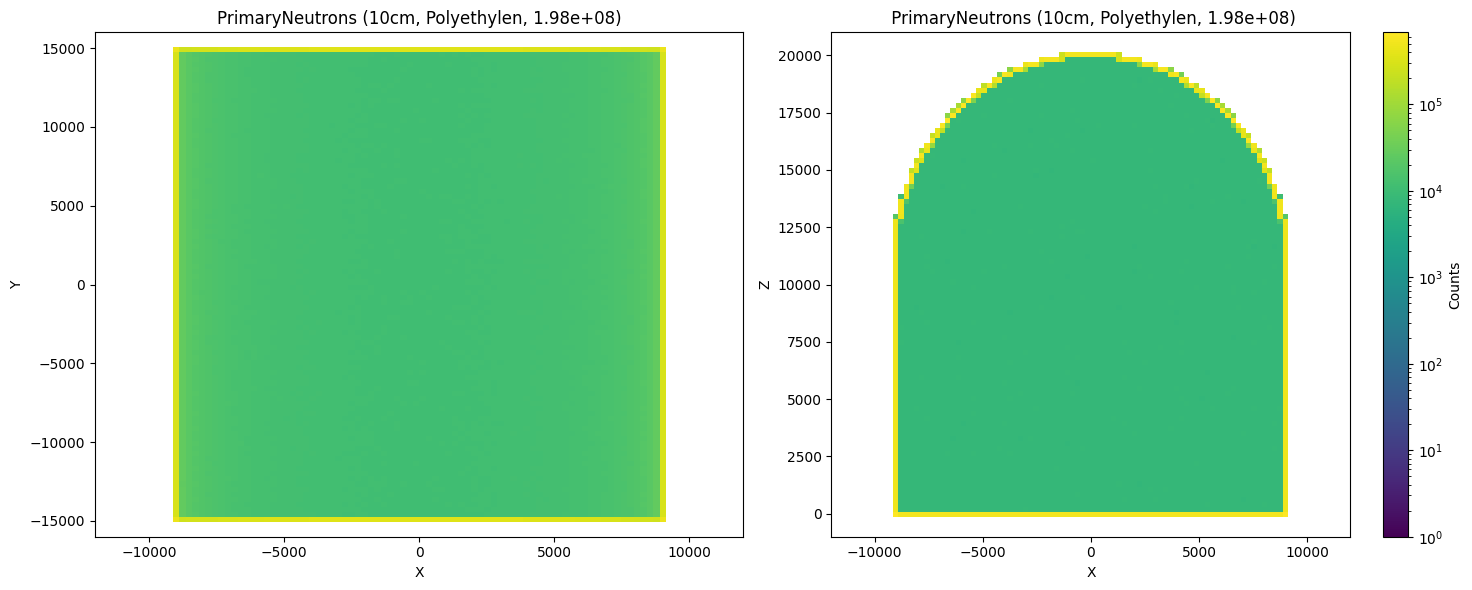

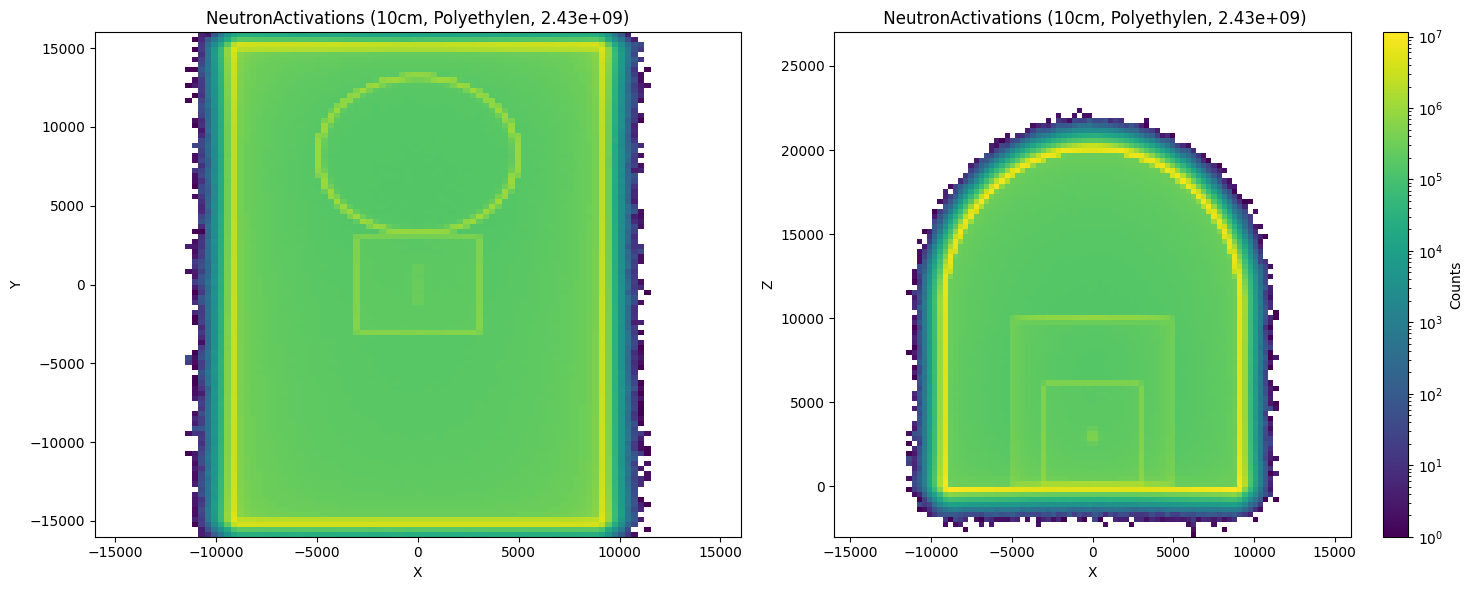

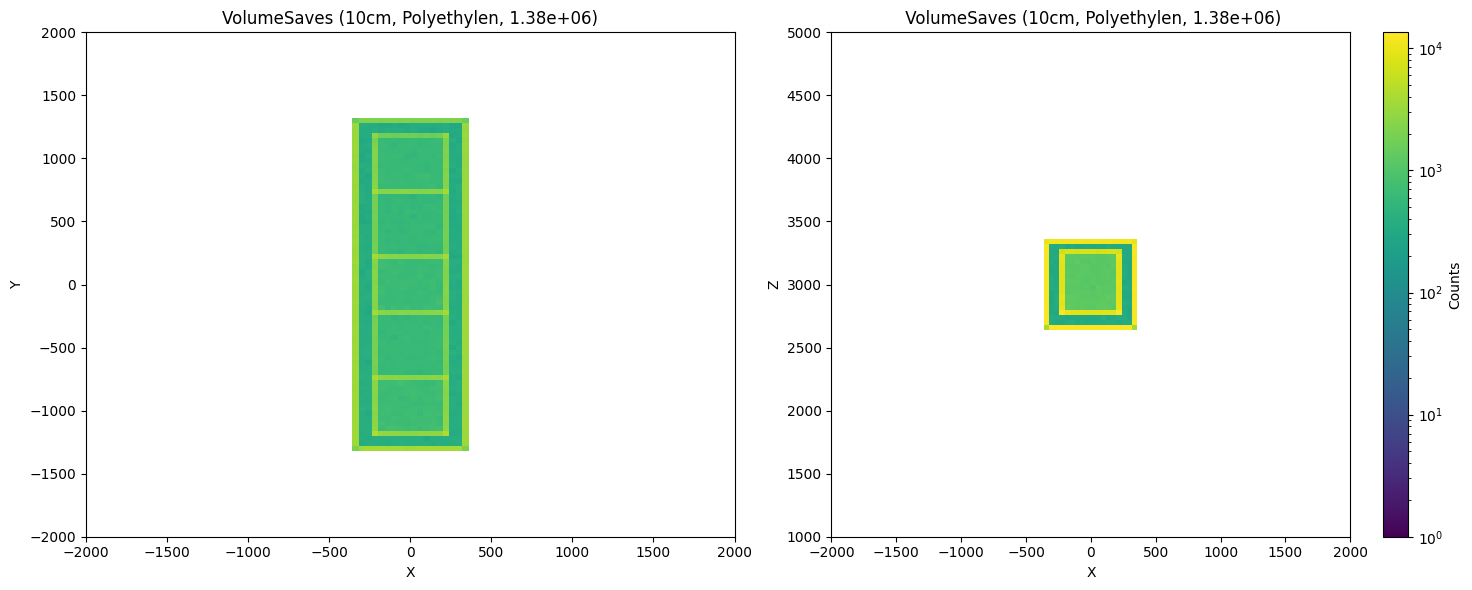

In [ ]:
grid = False

for i,coord in enumerate(coords):
    if i == 0:
        a='PrimaryNeutrons'
    elif i == 1:
        a='NeutronActivations'
    elif i == 2:
        a='VolumeSaves'

    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]

    xy_proj = h3d_computed[i][:,:,sum].view()
    xz_proj = h3d_computed[i][:,sum,:].view()
    max_val = max(xy_proj.max(), xz_proj.max())
    all = h3d_computed[i].sum()

    fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

    aspect = 'auto'

    norm = mpl.colors.LogNorm(vmin=1, vmax=max_val) 
    #norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.1)  # Use Normalize for linear scaling
    #aspect = 'equal'

    ax[0].imshow(
        xy_proj.T,  
        extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title(f'{a} ({path_length}, {path_Material}, {all:.2e})')



    # XZ-Projektion (Summe über y)
    ax[1].imshow(
        xz_proj.view().T,
        extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Z')
    ax[1].set_title(f' {a} ({path_length}, {path_Material}, {all:.2e})')

    if grid:
        ax[0].minorticks_on()
        ax[0].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[0].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')
        ax[1].minorticks_on()
        ax[1].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[1].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')

    fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
    plt.tight_layout()

    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Positions_{a}.pdf" )
    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Positions_{a}.png" )
    plt.show()